# 03 — Demand Allocation: Distribute 2027 EV Fleet Across Corridors

**Objective:** Take the projected 2027 EV fleet (614,412 from Model_1) and distribute it geographically across Spain's provinces and interurban road corridors to estimate **charging demand per route segment**.

**Inputs:**
- `total_ev_projected_2027 = 614,412` (from [Model_1.ipynb](https://github.com/moanv2/Laboratorio-de-Datos/blob/datathon-2026/Data%20Science/Ruta%20a%20la%20electrificaci%C3%B3n%20de%20la%20Movilidad/Codigo/Model_1.ipynb))
- DGT microdata (province-level BEV distribution, Oct 2024 – Dec 2025)
- Road network from notebook 01

**Output:** `demand_by_corridor.csv` — estimated EV demand per interurban corridor


In [4]:
# Install dependencies (Colab)
# !pip install geopandas pandas numpy matplotlib -q

import geopandas as gpd
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ── Core parameter from Model_1 ──
TOTAL_EV_2027 = 614_412  # from SARIMA forecast (flow -> stock conversion)
print(f"Total EV fleet projected for 2027: {TOTAL_EV_2027:,}")


Total EV fleet projected for 2027: 614,412


## 1. EV registrations by province

Province-level BEV registration shares from **DGT monthly microdata** (Oct-Dec 2024 + Oct-Dec 2025, 52,371 BEV passenger car registrations).

**Source:** [DGT Microdatos — Matriculaciones](https://www.dgt.es/menusecundario/dgt-en-cifras/matraba-listados/matriculaciones-automoviles-mensual.html)

Parsed from fixed-width `export_mensual_mat_YYYYMM.txt` files using the official [record layout](https://sedeapl.dgt.gob.es/IEST_INTER/pdfs/disenoRegistro/vehiculos/matriculaciones/MATRICULACIONES_MATRABA.pdf). Filtered by `COD_TIPO=40` (passenger car) and `CATEGORÍA_VEHÍCULO_ELÉCTRICO=BEV`.

**6 months**: 52k obs (Oct - Dec 2024 + Oct - Dec 2025)


In [5]:
# ── Province-level BEV distribution from DGT microdata ──
# Parsed from DGT monthly microdata files (Oct-Dec 2024 + Oct-Dec 2025)
# 52,371 BEV passenger car registrations by COD_PROVINCIA_MAT

DGT_CSV = "../data/processed/dgt_province_ev_distribution.csv"

if os.path.exists(DGT_CSV):
    prov_df = pd.read_csv(DGT_CSV)
    print(f"Loaded DGT province distribution: {len(prov_df)} provinces")
    print(f"  Source: DGT microdata (Oct-Dec 2024 + Oct-Dec 2025)")
    print(f"  Total BEV registrations: {prov_df['bev_registrations'].sum():,}")

    # Build province shares indexed by INE code
    province_shares = prov_df.set_index('province_code_ine')['share']
    province_shares = province_shares.sort_values(ascending=False)

    print(f"\nTop 15 provinces by BEV share:")
    for idx, share in province_shares.head(15).items():
        name = prov_df[prov_df['province_code_ine']==idx]['province_name'].values[0]
        print(f"  {name:<25s} (INE {idx:02d}): {share*100:5.1f}%")

else:
    # Fallback: hardcoded from DGT microdata analysis (same source, embedded)
    print(f"WARNING: {DGT_CSV} not found. Using embedded DGT distribution.")
    province_shares = pd.Series({
        28: 0.49207, 8: 0.12936, 46: 0.03054, 3: 0.02755, 35: 0.02692,
        29: 0.02608, 50: 0.02274, 7: 0.01819, 39: 0.01615, 38: 0.01514,
        14: 0.01422, 41: 0.01281, 45: 0.01103, 31: 0.00987, 48: 0.00957,
        30: 0.00945, 33: 0.00920, 18: 0.00907, 36: 0.00863, 15: 0.00836,
        9: 0.00786, 4: 0.00721, 23: 0.00702, 47: 0.00641, 11: 0.00622,
        43: 0.00603, 17: 0.00586, 20: 0.00565, 12: 0.00540, 24: 0.00521,
        32: 0.00471, 6: 0.00461, 19: 0.00448, 1: 0.00440, 27: 0.00421,
        26: 0.00389, 21: 0.00362, 22: 0.00290, 37: 0.00267, 10: 0.00267,
        40: 0.00250, 16: 0.00233, 2: 0.00225, 34: 0.00118, 5: 0.00116,
        13: 0.00110, 44: 0.00105, 49: 0.00063, 51: 0.00057, 42: 0.00055,
        52: 0.00040, 25: 0.00034,
    }).sort_values(ascending=False)

    # Ensure shares sum to 1.0
    province_shares = province_shares / province_shares.sum()

# Scale to 2027 fleet
province_fleet = (province_shares * TOTAL_EV_2027).round(0).astype(int)
print(f"\n2027 EV fleet by province (top 10):")
for prov, count in province_fleet.head(10).items():
    print(f"  Province {prov:02d}: {count:>8,} EVs")
print(f"  Total:        {province_fleet.sum():>8,}")


Loaded DGT province distribution: 52 provinces
  Source: DGT microdata (Oct-Dec 2024 + Oct-Dec 2025)
  Total BEV registrations: 52,371

Top 15 provinces by BEV share:
  Madrid                    (INE 28):  49.2%
  Barcelona                 (INE 08):  12.9%
  Valencia                  (INE 46):   3.1%
  Alicante                  (INE 03):   2.8%
  Las Palmas                (INE 35):   2.7%
  Málaga                    (INE 29):   2.6%
  Zaragoza                  (INE 50):   2.3%
  Illes Balears             (INE 07):   1.8%
  Cantabria                 (INE 39):   1.6%
  Santa Cruz de Tenerife    (INE 38):   1.5%
  Córdoba                   (INE 14):   1.4%
  Sevilla                   (INE 41):   1.3%
  Toledo                    (INE 45):   1.1%
  Navarra                   (INE 31):   1.0%
  Bizkaia                   (INE 48):   1.0%

2027 EV fleet by province (top 10):
  Province 28:  302,297 EVs
  Province 08:   79,486 EVs
  Province 46:   18,770 EVs
  Province 03:   16,927 EVs
  Provinc

## 2. Map provinces to interurban corridors

Each province generates long-distance EV trips on specific corridors. We weight by corridor importance (proxy for traffic share).

### Key corridors:
- **Mediterranean axis:** AP-7 / A-7 (Barcelona → Valencia → Murcia → Almería)
- **Radial from Madrid:** A-1 (north), A-2 (Barcelona), A-3 (Valencia), A-4 (Andalucía), A-5 (Extremadura), A-6 (Galicia)
- **Cantabrian coast:** A-8 (Bilbao → Santander → Gijón → A Coruña)
- **Ebro valley:** AP-2 / AP-68 (Bilbao → Zaragoza → Barcelona)
- **Andalucian:** A-92, AP-4 (Sevilla → Granada → Málaga)


In [6]:
# ── Define major corridor structure ──
# Each corridor connects provinces (INE codes) and carries a weight (traffic share proxy)

CORRIDORS = {
    # Mediterranean axis
    'AP-7': {'provinces': [8, 43, 12, 46, 3, 30, 4], 'weight': 1.0, 'length_km': 1100},
    'A-7':  {'provinces': [8, 43, 12, 46, 3, 30, 4, 29, 18, 4], 'weight': 0.8, 'length_km': 1300},

    # Radial from Madrid
    'A-1':  {'provinces': [28, 19, 9, 1], 'weight': 0.7, 'length_km': 320},
    'A-2':  {'provinces': [28, 19, 50, 25, 8], 'weight': 0.9, 'length_km': 620},
    'A-3':  {'provinces': [28, 16, 46], 'weight': 0.7, 'length_km': 350},
    'A-4':  {'provinces': [28, 13, 23, 14, 41], 'weight': 0.8, 'length_km': 530},
    'A-5':  {'provinces': [28, 45, 6, 10], 'weight': 0.5, 'length_km': 400},
    'A-6':  {'provinces': [28, 47, 24, 27, 15], 'weight': 0.6, 'length_km': 600},

    # Northern
    'A-8':  {'provinces': [48, 39, 33, 27, 15], 'weight': 0.6, 'length_km': 480},
    'AP-68':{'provinces': [48, 26, 50], 'weight': 0.4, 'length_km': 300},

    # Ebro
    'AP-2': {'provinces': [50, 25, 8], 'weight': 0.5, 'length_km': 300},

    # Andalucia
    'A-92': {'provinces': [41, 18, 4], 'weight': 0.5, 'length_km': 350},
    'AP-4': {'provinces': [41, 11], 'weight': 0.4, 'length_km': 120},
    'A-44': {'provinces': [23, 18], 'weight': 0.3, 'length_km': 200},

    # Nacional roads (key N- routes)
    'N-340':{'provinces': [8, 43, 12, 46, 3, 30, 4], 'weight': 0.3, 'length_km': 1200},
    'N-II': {'provinces': [28, 19, 50, 25, 8], 'weight': 0.3, 'length_km': 600},
    'N-I':  {'provinces': [28, 9, 20], 'weight': 0.3, 'length_km': 470},
    'N-III':{'provinces': [28, 16, 46], 'weight': 0.2, 'length_km': 350},
    'N-IV': {'provinces': [28, 13, 23, 14, 41, 11], 'weight': 0.3, 'length_km': 620},
}

print(f"Defined {len(CORRIDORS)} major interurban corridors")
total_km = sum(c['length_km'] for c in CORRIDORS.values())
print(f"Total corridor length: {total_km:,} km")


Defined 19 major interurban corridors
Total corridor length: 10,210 km


In [7]:
# ── Allocate EV demand to corridors ──

corridor_demand = {}
for corridor, info in CORRIDORS.items():
    # Sum EVs in connected provinces
    connected_evs = sum(province_fleet.get(p, 0) for p in info['provinces'])
    demand = connected_evs * info['weight']

    corridor_demand[corridor] = {
        'connected_evs': connected_evs,
        'weight': info['weight'],
        'raw_demand': demand,
        'length_km': info['length_km'],
        'demand_per_km': demand / info['length_km'] if info['length_km'] > 0 else 0,
    }

df_corridors = pd.DataFrame(corridor_demand).T
df_corridors = df_corridors.sort_values('demand_per_km', ascending=False)

print("Corridor demand ranking (by demand density per km):")
print(df_corridors[['connected_evs', 'weight', 'raw_demand', 'length_km', 'demand_per_km']].to_string())


Corridor demand ranking (by demand density per km):
       connected_evs  weight  raw_demand  length_km  demand_per_km
A-1         309517.0     0.7    216661.9      320.0     677.068437
A-3         321337.0     0.7    224935.9      350.0     642.674000
A-2         402274.0     0.9    362046.6      620.0     583.946129
A-4         324471.0     0.8    259576.8      530.0     489.767547
A-5         312982.0     0.5    156491.0      400.0     391.227500
A-6         315740.0     0.6    189444.0      600.0     315.740000
N-II        402274.0     0.3    120682.2      600.0     201.137000
N-I         307329.0     0.3     92198.7      470.0     196.167447
N-III       321337.0     0.2     64267.4      350.0     183.621143
AP-2         96800.0     0.5     48400.0      300.0     161.333333
N-IV        327605.0     0.3     98281.5      620.0     158.518548
AP-7        127717.0     1.0    127717.0     1100.0     116.106364
A-7         150537.0     0.8    120429.6     1300.0      92.638154
A-8       

## 3. Estimate charging sessions per corridor

Convert EV fleet demand into **peak daily charging sessions** on interurban roads.

**Assumptions:**
- Interurban trips per EV: **2 round-trips/month** (conservative)
- Charging stop probability per trip: **0.8**
- Design peak factor: **1.5×** average (holidays, weekends)


In [8]:
# ── Charging demand model ──

TRIPS_PER_MONTH = 2
CHARGE_PROBABILITY = 0.8
PEAK_FACTOR = 1.5
DAYS_PER_MONTH = 30

for corridor in df_corridors.index:
    evs = df_corridors.loc[corridor, 'connected_evs']
    weight = df_corridors.loc[corridor, 'weight']

    monthly_trips = evs * TRIPS_PER_MONTH * weight
    monthly_sessions = monthly_trips * CHARGE_PROBABILITY
    peak_daily = (monthly_sessions / DAYS_PER_MONTH) * PEAK_FACTOR

    df_corridors.loc[corridor, 'monthly_trips'] = monthly_trips
    df_corridors.loc[corridor, 'peak_daily_sessions'] = peak_daily

df_corridors = df_corridors.sort_values('peak_daily_sessions', ascending=False)
print("Peak daily charging sessions by corridor:")
print(df_corridors[['length_km', 'connected_evs', 'peak_daily_sessions']].head(15).to_string())

print(f"\nTotal peak daily sessions across all corridors: "
      f"{df_corridors['peak_daily_sessions'].sum():,.0f}")


Peak daily charging sessions by corridor:
       length_km  connected_evs  peak_daily_sessions
A-2        620.0       402274.0            28963.728
A-4        530.0       324471.0            20766.144
A-3        350.0       321337.0            17994.872
A-1        320.0       309517.0            17332.952
A-6        600.0       315740.0            15155.520
A-5        400.0       312982.0            12519.280
AP-7      1100.0       127717.0            10217.360
N-II       600.0       402274.0             9654.576
A-7       1300.0       150537.0             9634.368
N-IV       620.0       327605.0             7862.520
N-I        470.0       307329.0             7375.896
N-III      350.0       321337.0             5141.392
AP-2       300.0        96800.0             3872.000
N-340     1200.0       127717.0             3065.208
A-8        480.0        29363.0             1409.424

Total peak daily sessions across all corridors: 172,806


## 4. Visualize demand distribution

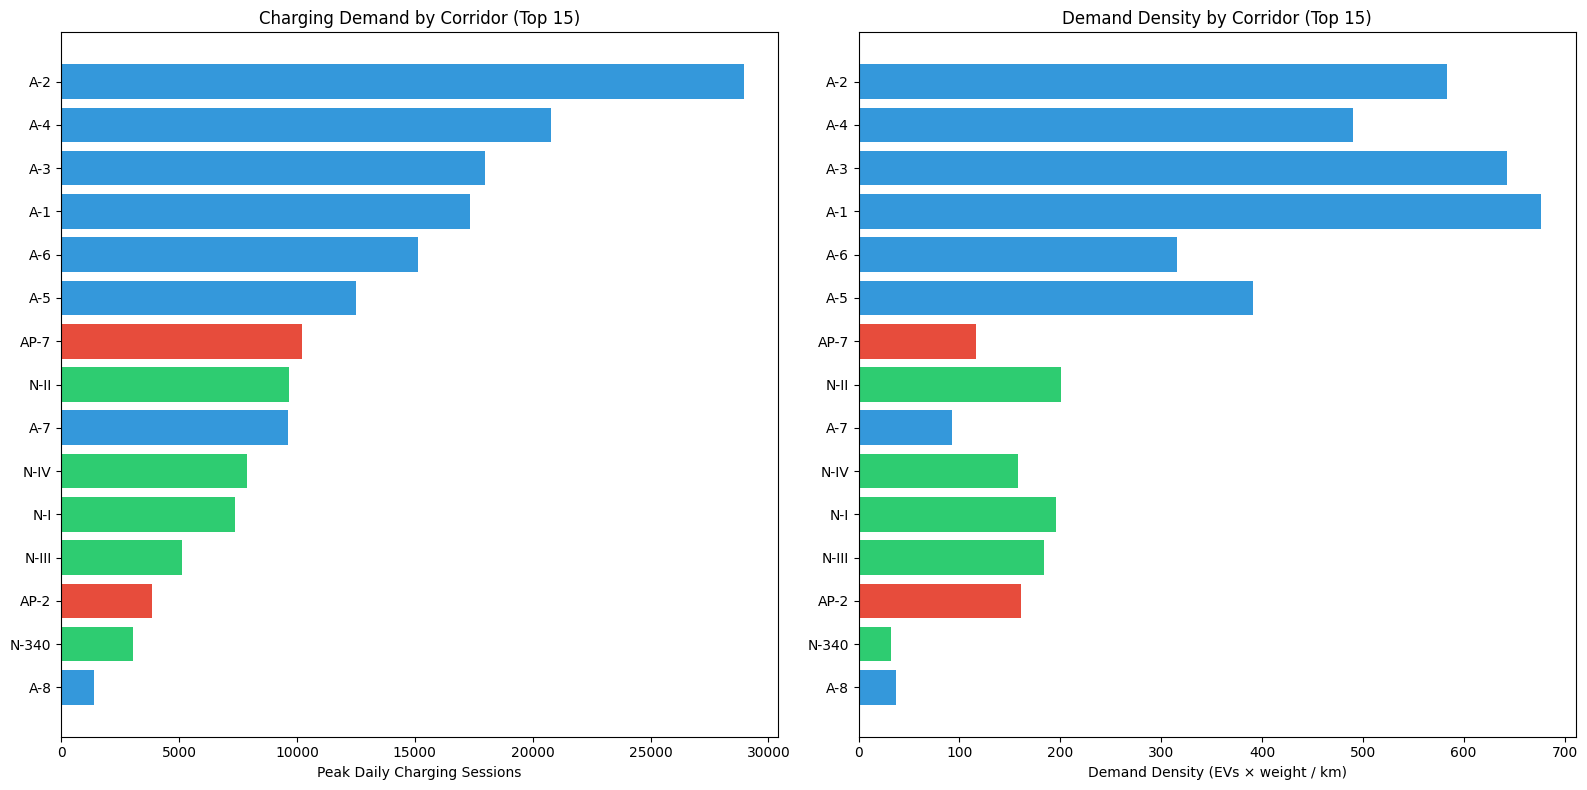

In [9]:
# ── Bar chart of demand by corridor ──

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

top = df_corridors.head(15)
colors = []
for idx in top.index:
    if idx.startswith('AP-'):
        colors.append('#e74c3c')
    elif idx.startswith('A-'):
        colors.append('#3498db')
    else:
        colors.append('#2ecc71')

ax1.barh(top.index[::-1], top['peak_daily_sessions'].values[::-1], color=colors[::-1])
ax1.set_xlabel('Peak Daily Charging Sessions')
ax1.set_title('Charging Demand by Corridor (Top 15)')

ax2.barh(top.index[::-1], top['demand_per_km'].values[::-1], color=colors[::-1])
ax2.set_xlabel('Demand Density (EVs × weight / km)')
ax2.set_title('Demand Density by Corridor (Top 15)')

plt.tight_layout()
plt.show()


## 5. Save demand allocation

In [10]:
# ── Save corridor demand for downstream notebooks ──

OUTPUT_PATH = "../data/processed/demand_by_corridor.csv"
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

df_corridors.to_csv(OUTPUT_PATH)
print(f"Saved {len(df_corridors)} corridors -> {OUTPUT_PATH}")
print(f"Total peak daily sessions: {df_corridors['peak_daily_sessions'].sum():,.0f}")
print(f"\nThis feeds into notebook 04 (station placement).")


Saved 19 corridors -> ../data/processed/demand_by_corridor.csv
Total peak daily sessions: 172,806

This feeds into notebook 04 (station placement).
